In [ ]:
import cfe

# cfe.logger.setLevel("INFO")
cfe.logger.setLevel("DEBUG")

# cfe.settings.backend = "python_function"
cfe.settings.backend = "conda"
# cfe.settings.backend = "cfe_docker"

cfe.settings.save_external_data = True # save external data
cfe.settings.save_h5ad = True # save external data

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

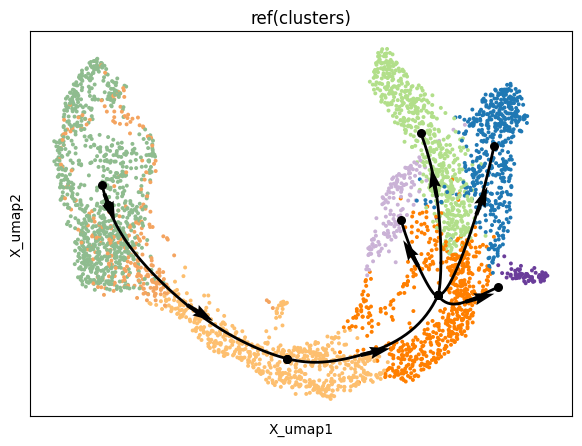

In [2]:
fadata = cfe.data.read_pancrease()
del fadata.uns["neighbors"] # velocity neighbor info error, need recalculate
cfe.plot.plot_trajectory(fadata)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'stavia' is available: Python 3.10.14                                                                                                                                   
DEBUG    |- Loaded function 'stavia': <function stavia at 0x75d38658f490>                                                                                                                               
INFO     |- method backend loaded: CondaBackend: stavia in conda env 'stavia'                                                                                                                           
DEBUG    |- set new log file: .cfe/pancreas/log/20251118_094556__stavia-conda__wKc5ffQb9J.log                                                                                                       

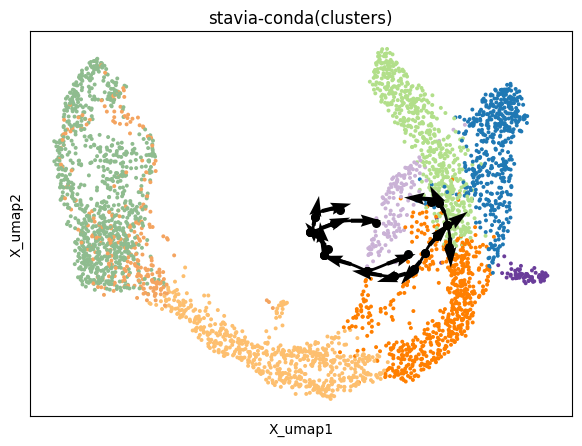

In [ ]:
method2parameters = {
    # "scvelo": {},
    # "dynamo": {},
    # "palantir": {},
    "stavia": {"prune_milestone": False}, # 不剪枝效果更好
    # "cytotrace2": {},
    # "veloae": {},
    # "pyrovelocity": {},
    # "celldancer": {
    #     "velocity_kwargs": {"max_epoches": 200},
    #     "compute_cell_velocity_kwargs": {"projection_neighbor_size": 100},
    # }, # out of memory for large dataset
    # "unitvelo": {},
    # "sctc": {},
    # "cellrank": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True
    parameters["benchmark_resource"] = True  # record resource usage
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    # save in time, without waiting for all methods to finish, waypoint are not calculated
    fadata.write_trajectory_dict(model_name_list=[fadata.model_name])
    cfe.plot.plot_trajectory(fadata, save=True)
    

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory                                                                                                                                                                             
DEBUG    |- 'ref' is not a valid random_time_string, don't need parse                                                                                                                                   
DEBUG    |- plot_trajectory                                                                                                                                                                             
DEBUG    |- 'ref' is not a valid random_time_string, don't need parse                                                                                                                               

<Axes: title={'center': 'stavia-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

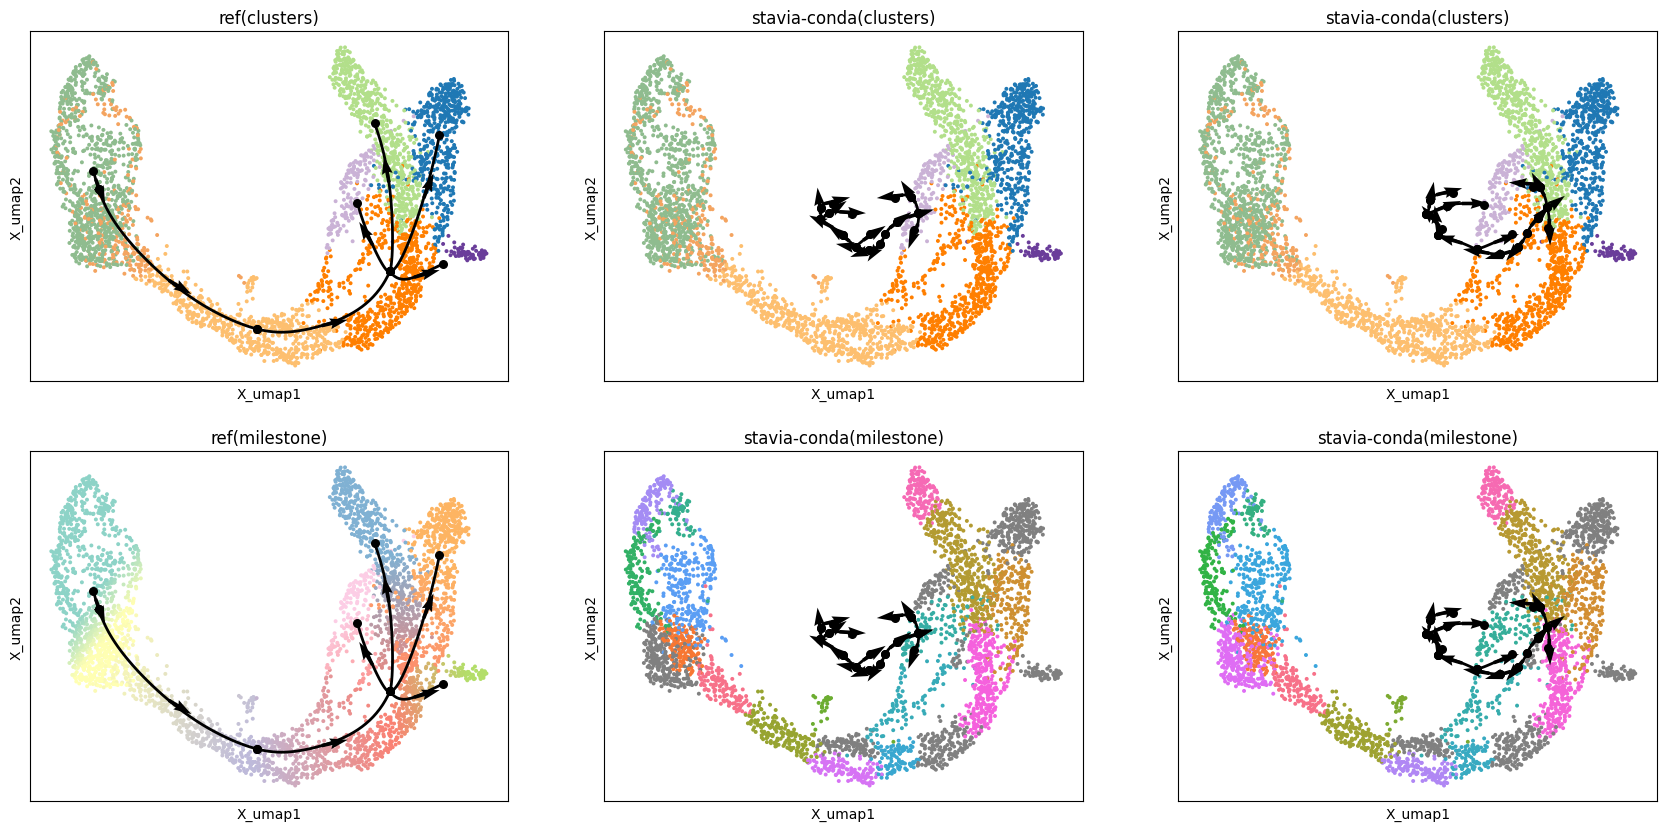

In [5]:
model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [ ]:
fadata.write_trajectory_dict() 

DEBUG    |- write trajectory 'ref' to '.cfe/pancreas/trajectory_history/ref.pkl'                                                                                                                        
DEBUG    |- write trajectory '20251117_192530__celldancer-conda__8iLKN1C0po' to '.cfe/pancreas/trajectory_history/20251117_192530__celldancer-conda__8iLKN1C0po.pkl'                                    
